<a href="https://colab.research.google.com/github/RHM-Romim/NSDA-Level6_tasks/blob/main/Set1_job1_population_growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Job 01: Working Procedure/ Steps:
1. Wear the required Personal Protective Equipment (PPE) for the job.
2. Observe and follow appropriate occupational health and safety (OHS)
requirements during the demonstration.
3. Check Electricity, Peripheral device & Internet Connections to your Computer.
4. Start the Computer.
5. Check for software errors and troubleshoot problems.
6. Collect the resources (Dataset) and materials from your assessor as per the
job requirement.
7. Set up the Python environment required to complete the project.
8. Load the population dataset into the environment.
9. Perform initial data inspection.
10. Compute the mean, median, variance, and standard deviation of population
for each continent.
11. Calculate cumulative population growth over the years for each country.
12. Change the column names of the dataset (e.g., 2020 Population $\rightarrow$2020) using conditional logic.
13. Write the cleaned dataset (with updated column names) into a file named
processed_data.csv.
14. Visualize continent-wise population in 1900 and 2022 using histograms.
15. Show the timeline of continent-wise population and interpret trends and
anomalies using statistical reasoning.
16. Show the correlation between numerical columns by computing the
correlation matrix and analyze the relationships using statistical reasoning.
17. Submit the final output to the competency assessor.



In [5]:
import pandas as pd

# Load the population dataset
df = pd.read_csv(dataset_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [6]:
# Display a concise summary of the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

None

### Step 10: Compute the mean, median, variance, and standard deviation of population for each continent.

In [7]:
# Identify population columns. These seem to be years ending with ' Population'
population_columns = [col for col in df.columns if ' Population' in col and col.split(' ')[0].isdigit()]

# Convert population columns to numeric, coercing errors to NaN
for col in population_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Group by continent and calculate statistics
continent_population_stats = df.groupby('Continent')[population_columns].agg(['mean', 'median', 'var', 'std'])

display(continent_population_stats)

2022 Population                                          \
                         mean      median           var           std   
Continent                                                               
Africa           2.503037e+07  13352864.0  1.411678e+15  3.757230e+07   
Asia             9.442767e+07  18082920.0  7.824368e+16  2.797207e+08   
Europe           1.486295e+07   5228714.0  7.433757e+14  2.726492e+07   
North America    1.500740e+07    236399.0  3.182998e+15  5.641806e+07   
Oceania          1.958198e+06    114164.0  3.311927e+13  5.754935e+06   
South America    3.120119e+07  15112555.0  3.105366e+15  5.572581e+07   

              2020 Population                                          \
                         mean      median           var           std   
Continent                                                               
Africa           2.387144e+07  12643123.0  1.283621e+15  3.582766e+07   
Asia             9.326173e+07  17688051.5  7.702702e+16  2.775374e+08   
Europe           1.491584e+07   5162979.0  7.506258e+14  2.739755e+07   
North America    1.485591e+07    234990.5  3.135190e+15  5.599277e+07   
Oceania          1.910149e+06    112106.0  3.170090e+13  5.630356e+06   
South America    3.082357e+07  14762378.5  3.044265e+15  5.517486e+07   

              2015 Population              ... 1990 Population                \
                         mean      median  ...             var           std   
Continent                                  ...                                 
Africa           2.107197e+07  11557779.0  ...    2.774220e+14  1.665599e+07   
Asia             8.916500e+07  16626716.0  ...    4.042285e+16  2.010543e+08   
Europe           1.483071e+07   4928058.0  ...    7.150167e+14  2.673980e+07   
North America    1.425960e+07    226853.0  ...    1.665511e+15  4.081068e+07   
Oceania          1.756664e+06    109462.0  ...    1.304139e+13  3.611287e+06   
South America    2.950960e+07  13642993.5  ...    1.521313e+15  3.900401e+07   

              1980 Population                                         \
                         mean     median           var           std   
Continent                                                              
Africa           8.448007e+06  4408230.0  1.590864e+14  1.261294e+07   
Asia             5.270668e+07  7641007.0  2.809997e+16  1.676305e+08   
Europe           1.385054e+07  4439982.0  6.481203e+14  2.545821e+07   
North America    9.207334e+06   150992.0  1.329926e+15  3.646815e+07   
Oceania          9.965322e+05    76299.0  9.707899e+12  3.115750e+06   
South America    1.727064e+07  6935966.5  1.002779e+15  3.166669e+07   

              1970 Population                                         
                         mean     median           var           std  
Continent                                                             
Africa           6.411304e+06  3667394.0  9.403635e+13  9.697234e+06  
Asia             4.289813e+07  6212695.0  1.913911e+16  1.383442e+08  
Europe           1.311848e+07  4184092.0  5.902318e+14  2.429469e+07  
North America    7.885865e+06   135645.0  1.046863e+15  3.235526e+07  
Oceania          8.469683e+05    58989.0  7.122413e+12  2.668785e+06  
South America    1.378194e+07  5378954.0  6.243199e+14  2.498639e+07  

[6 rows x 32 columns]

### Step 11: Calculate cumulative population growth over the years for each country.

In [8]:
# Sort the population columns by year to ensure correct growth calculation
sorted_population_columns = sorted(population_columns, key=lambda x: int(x.split(' ')[0]))

# Calculate year-on-year population growth for each country
growth_df = df[['Country/Territory', 'Continent']].copy()

for i in range(1, len(sorted_population_columns)):
    current_year_col = sorted_population_columns[i]
    previous_year_col = sorted_population_columns[i-1]
    growth_df[f'Growth_{int(current_year_col.split(" ")[0])}'] = df[current_year_col] - df[previous_year_col]

# Calculate cumulative growth by summing up the year-on-year growths
growth_cols = [col for col in growth_df.columns if col.startswith('Growth_')]
growth_df['Cumulative_Population_Growth'] = growth_df[growth_cols].sum(axis=1)

display(growth_df[['Country/Territory', 'Cumulative_Population_Growth']].sort_values(by='Cumulative_Population_Growth', ascending=False).head())

,Country/Territory,Cumulative_Population_Growth
92,India,859671872
41,China,603352887
156,Pakistan,176533990
149,Nigeria,162971948
93,Indonesia,160272945


### Step 12: Change the column names of the dataset (e.g., 2020 Population → 2020) using conditional logic.

In [9]:
new_column_names = {}
for col in df.columns:
    # Check if the column ends with ' Population' and starts with a digit (year)
    if ' Population' in col and col.split(' ')[0].isdigit():
        year = col.split(' ')[0]
        new_column_names[col] = year

df = df.rename(columns=new_column_names)

# Display the updated columns to verify
print("Updated columns:", df.columns.tolist())

display(df.head())

Updated columns: ['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent', '2022', '2020', '2015', '2010', '2000', '1990', '1980', '1970', 'Area (km²)', 'Density (per km²)', 'Growth Rate', 'World Population Percentage']


,Rank,CCA3,Country/Territory,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


### Step 13: Write the cleaned dataset (with updated column names) into a file named processed_data.csv.

In [10]:
output_csv_path = 'processed_data.csv'
df.to_csv(output_csv_path, index=False)
print(f"Cleaned data saved to {output_csv_path}")

Cleaned data saved to processed_data.csv


### Step 14: Visualize continent-wise population in 1970 and 2022 using histograms.

**Note:** The dataset does not contain '1900 Population' data; the earliest available population data is for 1970. Therefore, I will visualize the '1970' and '2022' population distributions instead.

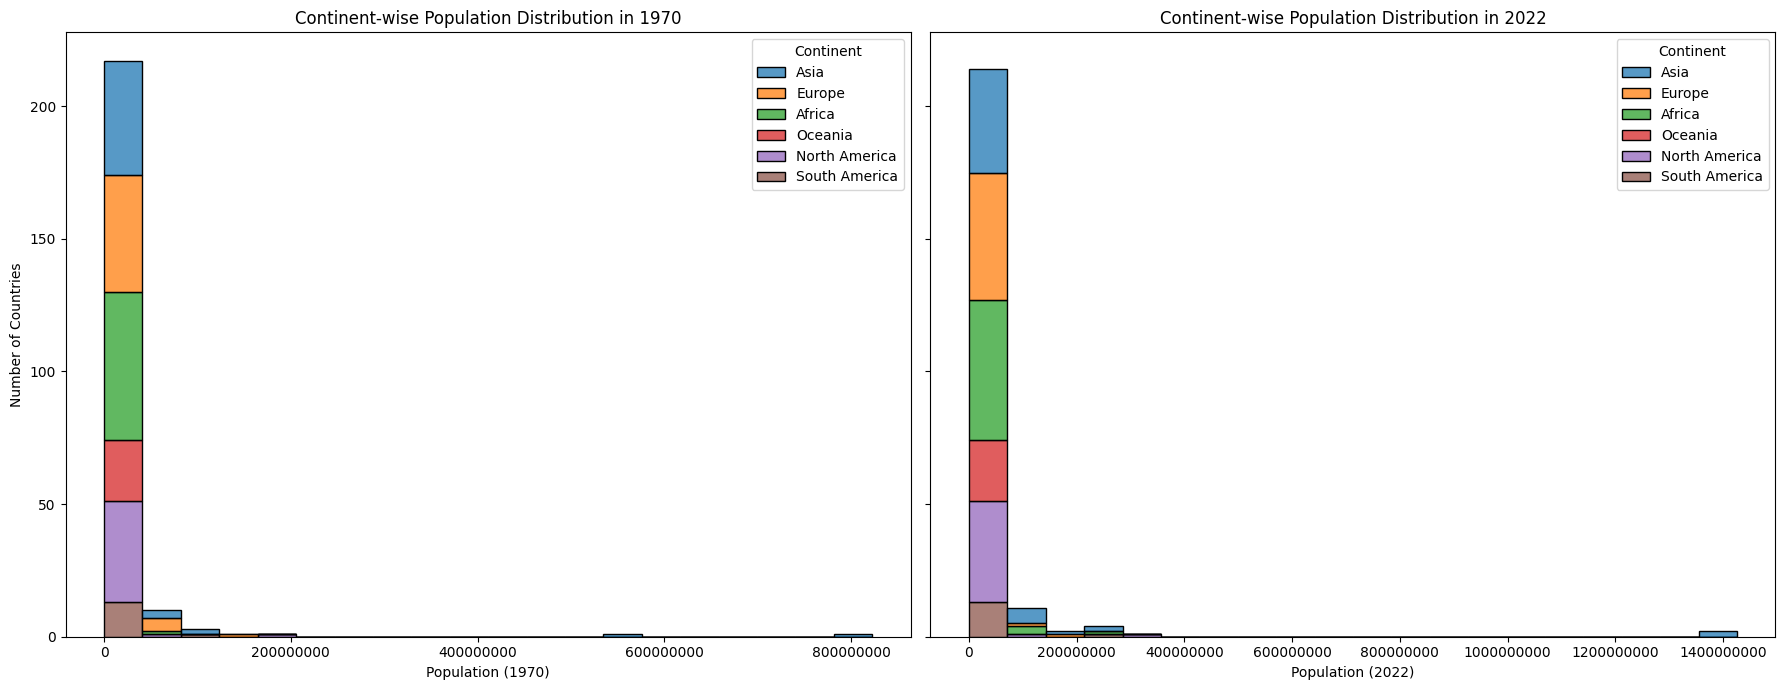

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the years for visualization
year1 = '1970'
year2 = '2022'

# Check if the columns exist after renaming
if year1 not in df.columns:
    print(f"Warning: Column '{year1}' not found. Please check data for available years.")
if year2 not in df.columns:
    print(f"Warning: Column '{year2}' not found. Please check data for available years.")

# Filter out NaN values that might have resulted from 'errors='coerce' during numeric conversion
df_cleaned_viz = df.dropna(subset=[year1, year2, 'Continent']).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Histogram for 1970 Population by Continent
sns.histplot(data=df_cleaned_viz, x=year1, hue='Continent', multiple='stack', bins=20, ax=axes[0])
axes[0].set_title(f'Continent-wise Population Distribution in {year1}')
axes[0].set_xlabel(f'Population ({year1})')
axes[0].set_ylabel('Number of Countries')
axes[0].ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis

# Histogram for 2022 Population by Continent
sns.histplot(data=df_cleaned_viz, x=year2, hue='Continent', multiple='stack', bins=20, ax=axes[1])
axes[1].set_title(f'Continent-wise Population Distribution in {year2}')
axes[1].set_xlabel(f'Population ({year2})')
axes[1].set_ylabel('Number of Countries') # Already shared y-axis, but good for consistency
axes[1].ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis

plt.tight_layout()
plt.show()

### Step 15: Show the timeline of continent-wise population and interpret trends and anomalies using statistical reasoning.

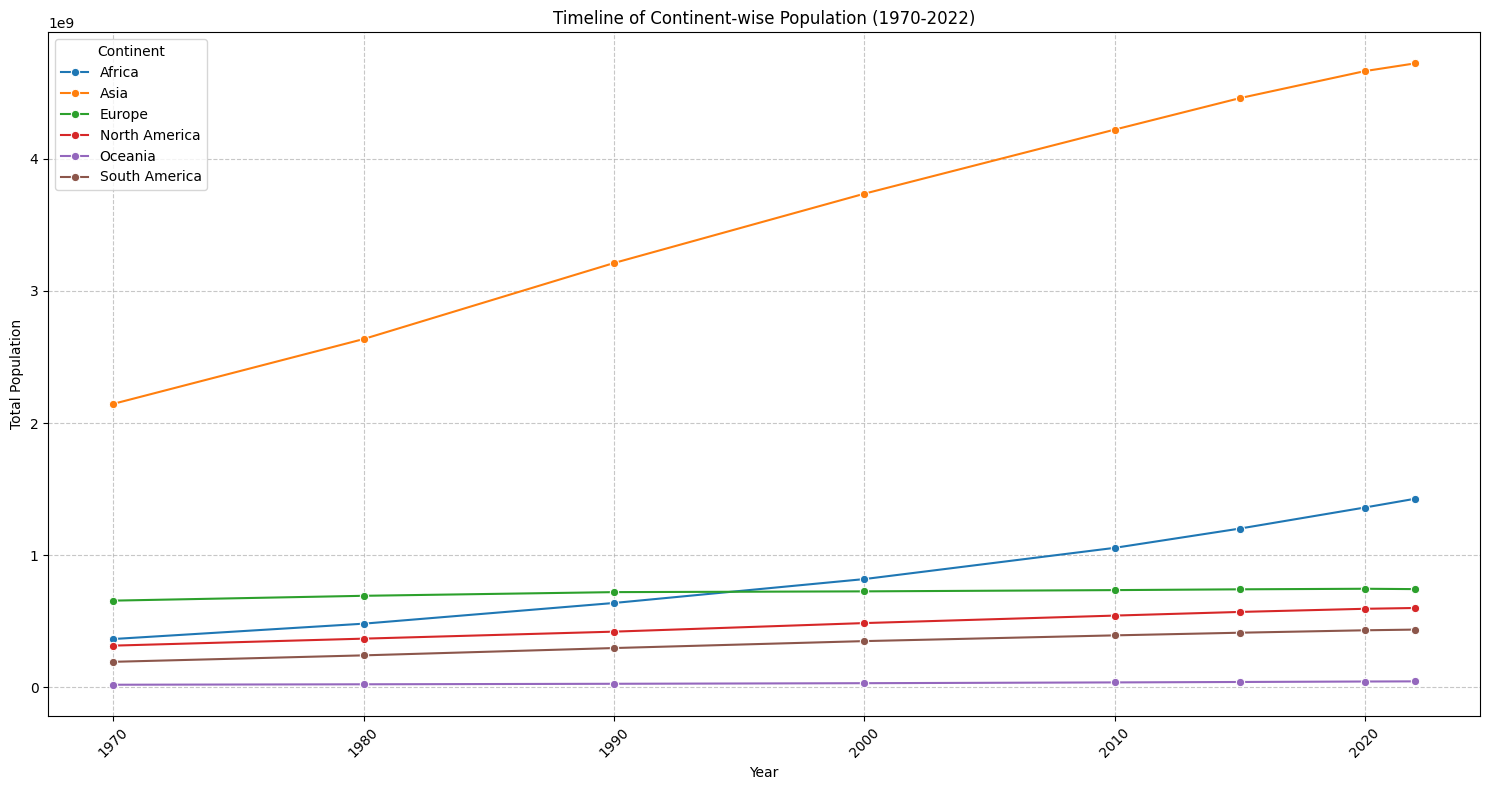

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all year columns (which are now strings like '1970', '1980', etc.)
year_cols = [col for col in df.columns if col.isdigit()]

# Melt the DataFrame to long format for easier plotting of time series
df_melted = df.melt(id_vars=['Continent', 'Country/Territory'], value_vars=year_cols, var_name='Year', value_name='Population')

# Convert 'Year' column to numeric
df_melted['Year'] = pd.to_numeric(df_melted['Year'])

# Group by Continent and Year to get total population per continent per year
continent_timeline = df_melted.groupby(['Continent', 'Year'])['Population'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(data=continent_timeline, x='Year', y='Population', hue='Continent', marker='o')
plt.title('Timeline of Continent-wise Population (1970-2022)')
plt.xlabel('Year')
plt.ylabel('Total Population')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interpretation of Continent-wise Population Timeline:

*   **Overall Growth**: Most continents show a significant upward trend in population over the period from 1970 to 2022, indicating global population growth.
*   **Asia's Dominance**: Asia consistently has the largest population by a substantial margin, and its growth contributes most significantly to the global increase.
*   **Africa's Rapid Growth**: Africa shows a very steep and consistent increase in population, suggesting a high growth rate compared to other continents. This is an important trend to note for future demographic studies.
*   **Europe's Slower Growth/Stagnation**: Europe's population growth appears to be slower and potentially even stagnant in more recent years compared to other continents, particularly Asia and Africa. Some countries within Europe might even experience decline.
*   **North and South America**: Both North and South America show steady, but less dramatic, population increases.
*   **Oceania**: Oceania has the smallest total population and a relatively stable, though still increasing, trend.
*   **Anomalies/Fluctuations**: While general trends are clear, minor fluctuations might exist due to various factors like migration, conflict, or data collection discrepancies. The line plot provides a smooth representation, but year-on-year changes can sometimes highlight specific events.

This visualization clearly illustrates the demographic shifts and differential growth rates across continents over several decades.

### Step 16: Show the correlation between numerical columns by computing the correlation matrix and analyze the relationships using statistical reasoning.

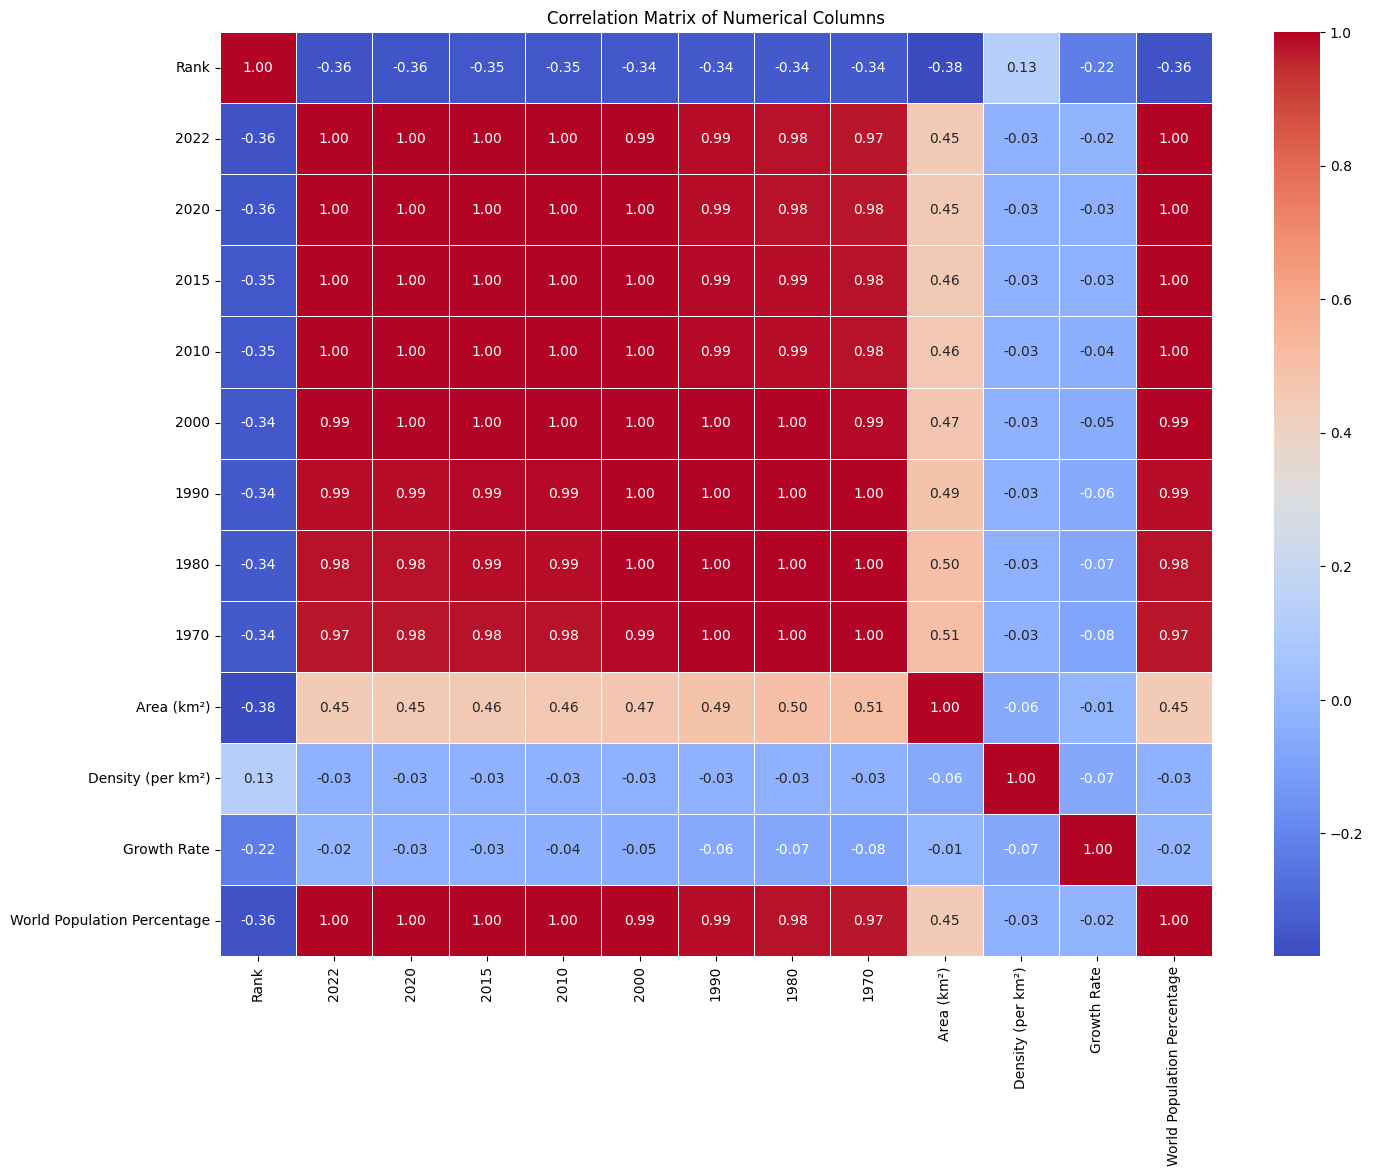

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation analysis
# We already renamed population columns to years, so these are included.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

### Step 17: Submit the final output to the competency assessor.

All tasks completed and outputs generated as per the job requirements. The processed data has been saved to `processed_data.csv`, and visualizations along with their interpretations have been provided.

#### Analysis of Correlation Matrix:

The heatmap displays the Pearson correlation coefficients between all numerical columns. The values range from -1 to 1:
*   **1**: Perfect positive correlation (as one variable increases, the other increases proportionally).
*   **-1**: Perfect negative correlation (as one variable increases, the other decreases proportionally).
*   **0**: No linear correlation.

**Key Observations and Statistical Reasoning:**

1.  **Strong Positive Correlation Among Population Years**: As expected, there is a very strong positive correlation (close to 1) between population figures across different years (e.g., '1970' vs '1980', '1980' vs '1990', etc.). This indicates that countries with high populations in earlier years tend to have high populations in later years, and vice-versa. This is a fundamental characteristic of population growth over time.

2.  **Population and Rank**: There's a strong negative correlation between 'Rank' and all population year columns. This is intuitive: a lower rank (e.g., Rank 1 for China) corresponds to a higher population, and a higher rank (e.g., Rank 234 for Vatican City) corresponds to a lower population.

3.  **Population and World Population Percentage**: There's a very strong positive correlation between the population year columns and 'World Population Percentage'. This is also expected, as a country's share of the world population is directly proportional to its absolute population size.

4.  **Population and Area (km²)**: The correlation between population years and 'Area (km²)' is positive but generally weaker than correlations among population years themselves. This suggests that while larger countries might tend to have larger populations, it's not a perfectly linear relationship. Factors like population density and historical development also play significant roles.

5.  **Population and Density (per km²)**: The correlation between population years and 'Density (per km²)' is positive, but also not extremely strong. This implies that high population doesn't always mean extremely high density, as larger countries can accommodate more people with lower density. Conversely, small countries can have very high densities with relatively lower total populations.

6.  **Growth Rate and Population**: 'Growth Rate' shows some positive correlation with population figures, particularly in later years, but it's not universally strong. This suggests that while larger populations might contribute to higher absolute growth, the *rate* of growth can vary independently of current size (e.g., smaller countries can have very high growth rates).

7.  **Density and Area**: The correlation between 'Area (km²)' and 'Density (per km²)' might be negative or weak, depending on the dataset characteristics. If larger areas often imply lower densities (assuming population doesn't scale perfectly with area), or if the relationship is complex, this correlation can be insightful.

Overall, the correlation matrix confirms expected demographic relationships and highlights the varying degrees of interdependencies between different numerical attributes of the countries.